Step 1: Import & Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


Step 2: Data Cleaning

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')

# 2. Exploratory Data Analysis (EDA)

## Total Sales

In [7]:
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 2261536.7827


## Sales Trend Over Time

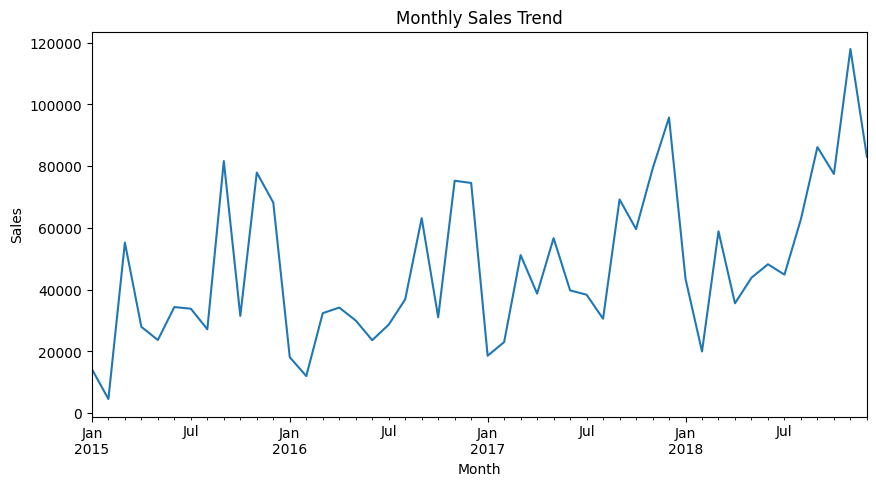

In [9]:
sales_trend = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

sales_trend.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

## Top Products

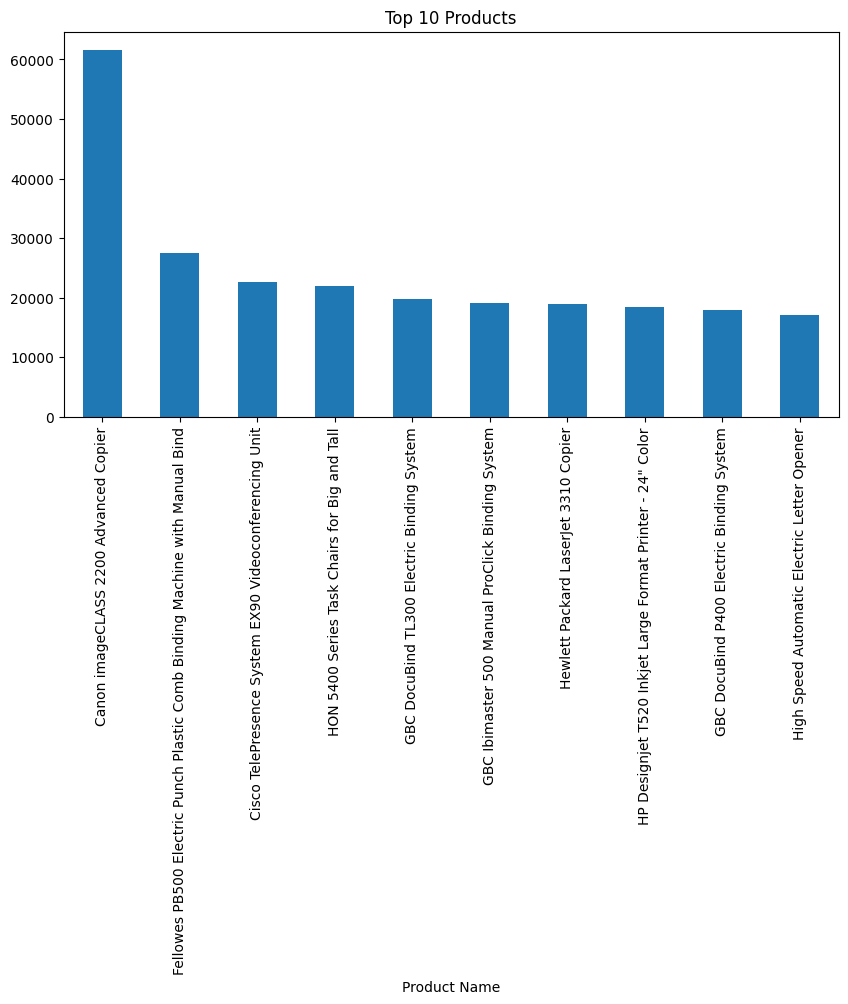

In [10]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Products")
plt.show()

## Sales by Category

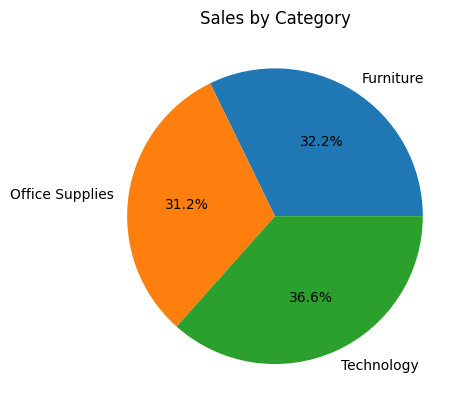

In [11]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Category")
plt.show()

## Sales by Region

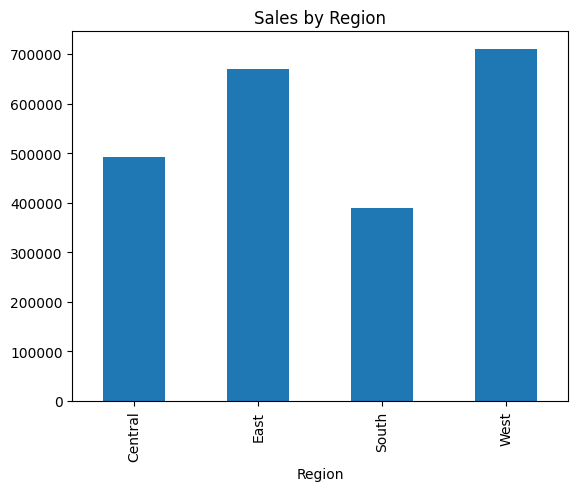

In [13]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.show()

## Sales by Customer Segment

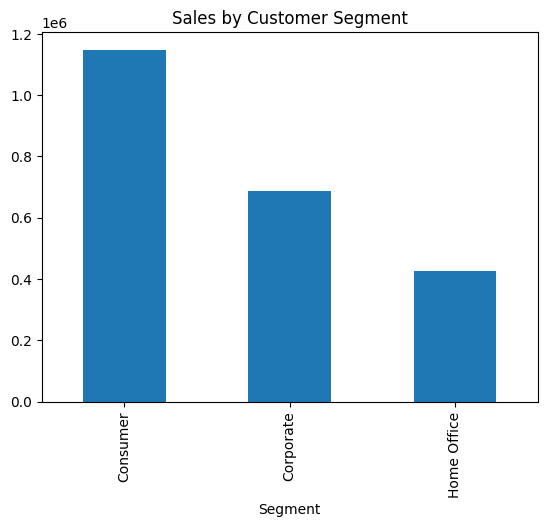

In [14]:
segment_sales = df.groupby('Segment')['Sales'].sum()

segment_sales.plot(kind='bar')
plt.title("Sales by Customer Segment")
plt.show()

## Sub-Category Analysis

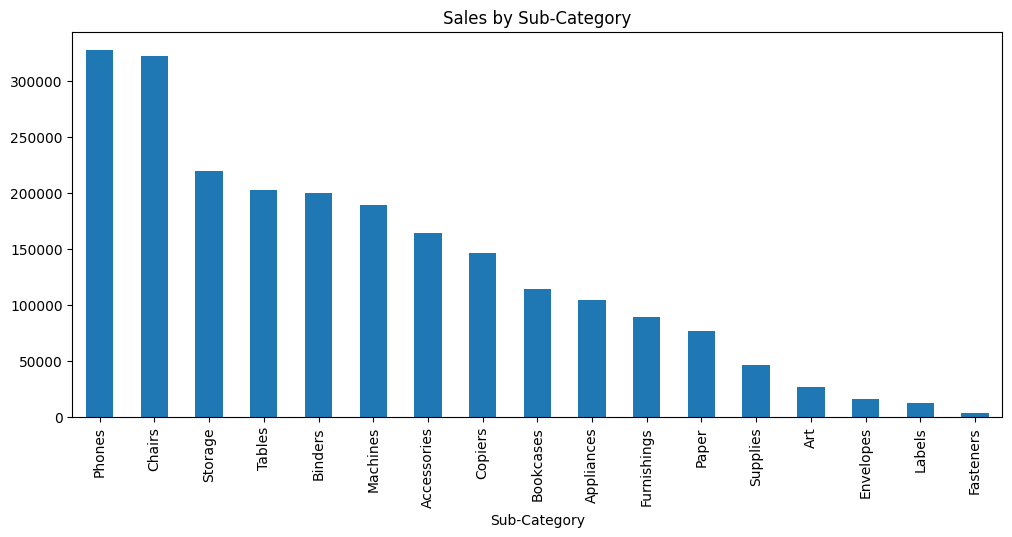

In [18]:
subcat = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

subcat.plot(kind='bar', figsize=(12,5))
plt.title("Sales by Sub-Category")
plt.show()

## Top Cities by Sales

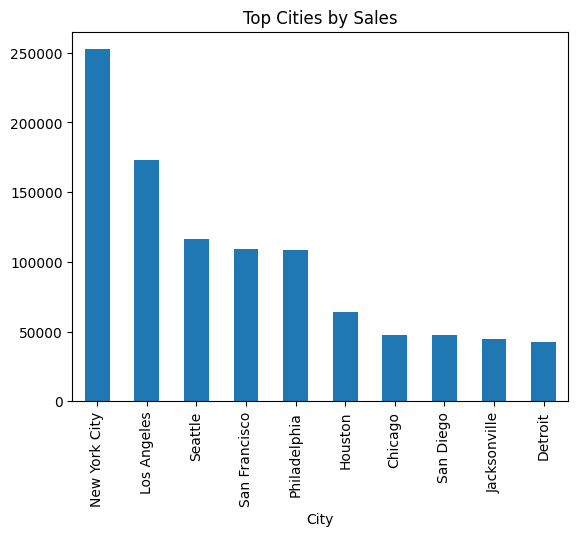

In [20]:
top_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)

top_cities.plot(kind='bar')
plt.title("Top Cities by Sales")
plt.show()

# 3. Customer Behavior Analysis (RFM)

## Step 1: Create RFM Table

In [15]:
import datetime as dt

snapshot_date = df['Order Date'].max() + dt.timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (snapshot_date - x.max()).days,
    'Order ID': 'count',
    'Sales': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,185,11,5563.560
AA-10375,20,15,1056.390
AA-10480,260,12,1790.512
AA-10645,56,18,5086.935
AB-10015,416,6,886.156


## Step 2: RFM Scoring

In [16]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm[['R_score','F_score','M_score']].sum(axis=1)

## Step 3: Customer Segments

In [17]:
def segment(score):
    if score >= 9:
        return 'High Value'
    elif score >= 5:
        return 'Medium Value'
    else:
        return 'Low Value'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

rfm['Segment'].value_counts()

Segment
Medium Value    363
High Value      312
Low Value       118
Name: count, dtype: int64